Unknown Structure in the Data

This analysis investigates whether patients naturally form groups based on their clinical characteristics without using region labels.

Unsupervised clustering techniques are used to identify potential hidden structures in the dataset.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("../Data/heart_cleaned.csv")

In [4]:
df_cluster = df.copy()

In [5]:
df_cluster = df_cluster.drop(columns=["country", "target", "ca"])

In [7]:
df_cluster["slope"] = df_cluster["slope"].fillna(0)
df_cluster["thal"] = df_cluster["thal"].fillna(0)


In [8]:
df_cluster = pd.get_dummies(df_cluster, drop_first=True)

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

In [10]:
X_scaled.shape

(918, 13)

Choosing the Number of Clusters

Before applying K-Means clustering, the optimal number of clusters should be explored.

The Elbow Method is used to evaluate how the within-cluster variation changes as the number of clusters increases.

In [11]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters= k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

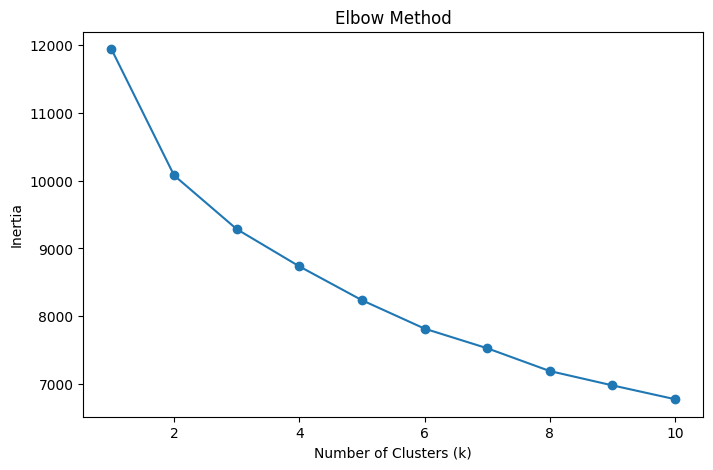

In [15]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1,11),
    inertia,
    marker = "o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [17]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k ={k}: {score: .3f}")

k =2:  0.157
k =3:  0.161
k =4:  0.150
k =5:  0.123
k =6:  0.128
k =7:  0.126
k =8:  0.118
k =9:  0.115
k =10:  0.123


Selecting the Number of Clusters

The Elbow Method suggested a possible elbow around 3–4 clusters.

To support the choice, silhouette scores were calculated for different values of k.

The highest silhouette score was obtained for k = 3 (0.161).

Although the score is relatively low, indicating that the clusters are not strongly separated, k = 3 provides the best balance between cluster compactness and separation.

Therefore, three clusters were selected for the subsequent analysis.

In [18]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)
df["clusters"] = clusters

In [19]:
df["clusters"].value_counts()

clusters
0    432
1    353
2    133
Name: count, dtype: int64

Can Patients Be Grouped Without Region Labels?

K-Means clustering was applied using clinical variables only. Region labels and the target variable were excluded from the clustering process.

The Elbow Method and silhouette analysis suggested that three clusters provide the most appropriate grouping structure.

The resulting cluster sizes were:

- Cluster 0: 432 patients
- Cluster 1: 353 patients
- Cluster 2: 133 patients

This suggests that patients can indeed be grouped based on their clinical characteristics alone, even without using region information.

These clusters resemble the known regions?

In [20]:
pd.crosstab(df["clusters"], df["country"], normalize="index")

country,Cleveland,Hungary,Switzerland,VA
clusters,,,,
0,0.312500,0.458333,0.101852,0.127315
1,0.348442,0.223796,0.206799,0.220963
2,0.338346,0.120301,0.037594,0.503759


Comparison with Known Regions

The resulting clusters only partially correspond to the known geographic regions.

Cluster 0 contains a larger proportion of patients from Hungary (46%), while Cluster 2 contains a larger proportion of patients from VA (50%). However, all clusters contain substantial numbers of patients from multiple regions.

Cluster 1 is particularly mixed, with patients from all four regions represented at comparable proportions.

Therefore, the clustering structure does not simply reproduce the geographic grouping. The data-driven clusters capture patterns that extend beyond regional differences and reflect similarities in clinical characteristics across regions.

In [21]:
df.groupby("clusters")[
    ["age", "thalach", "oldpeak", "chol"]
].mean()

,age,thalach,oldpeak,chol
clusters,,,,
0,49.622685,148.859808,0.286806,240.136574
1,56.280453,124.633225,1.505099,249.368272
2,58.924812,134.948092,0.974436,252.676692


In [22]:
df.groupby("clusters")["target"].mean()

clusters
0    0.344907
1    0.742210
2    0.669173
Name: target, dtype: float64

Which Grouping Appears More Informative?

The data-driven grouping appears more informative than the region-based grouping.

While the regional classification reveals geographic differences in disease prevalence, the clusters identify groups of patients with distinct clinical profiles.

The clusters differ substantially in age, maximum heart rate (thalach), ST depression (oldpeak), and heart disease prevalence. For example, Cluster 0 represents a lower-risk group with younger patients, higher maximum heart rates, and lower oldpeak values, whereas Clusters 1 and 2 represent higher-risk patient groups.

In contrast, the regional grouping mainly reflects geographic variation and does not capture these clinically meaningful patterns as directly.

Therefore, the clustering analysis suggests that patient characteristics provide a more informative basis for grouping than geographic region alone.